# Purpose

The purpose of this example notebook is to show how to use the `spectra` package for spectrum analysis and calculating the normalized dose as a function of `z`.

# Imports

In [1]:
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams
from spectra.normalizeddose import NormalizedDose

# Adjust source for darklevel
data.sources['HR3v3_365nm_Visitech'].power -= 0.006
data.sources['HR3v3_365nm_Visitech_370nm_shortpass'].power -= 0.006

# Orientation

## Spectrum data

The `spectra.data` package contains measured LED emission spectra and measured absorption spectra, as well as monomer information necessary to calculate normalized dose. To get an overview of what is in the package, execute the following command:

In [2]:
help(data)

Help on package spectra.data in spectra:

NAME
    spectra.data

PACKAGE CONTENTS
    absorbers (package)
    sources (package)

DATA
    absorbers = {'avobenzone_in_PEGDA': <spectra.absorberspectrum.Absorber...
    absorbers_directory = PosixPath('/Users/dallinminer/Documents/Research...
    material_abbreviations = {'Avobenzone': 'Avo', 'BLS99-2': 'B99', 'BME'...
    monomers = {'HDDA': Monomer(/Users/dallinminer/Documents/Research/3d.....
    monomers_directory = PosixPath('/Users/dallinminer/Documents/Research/...
    photoinitiators = {'irgacure_819_in_PEGDA': <spectra.absorberspectrum....
    photoinitiators_directory = PosixPath('/Users/dallinminer/Documents/Re...
    sources = {'HR3v3_365nm_Visitech': <spectra.sourcespectrum.SourceSpect...
    sources_directory = PosixPath('/Users/dallinminer/Documents/Research/3...

FILE
    /Users/dallinminer/Documents/Research/3dprinter_spectra_and_tools/spectra/data/__init__.py




The part to pay attention to is under DATA. Specifically, `absorbers`, `monomers`, `photoinitiators`, and `sources`. Note that each of these is a dict, the contents of which is shown below. 

In [3]:
print('Absorbers')
print('---------')
pprint(data.absorbers)
print()

print('Monomers')
print('--------')
pprint(data.monomers)
print()

print('Photoinitiators')
print('---------------')
pprint(data.photoinitiators)
print()

print('Sources')
print('-------')
pprint(data.sources)
print()

Absorbers
---------
{'avobenzone_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111c86b50>,
 'benetex_obplus_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111f8a2d0>,
 'bls_99-2_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111da9e50>,
 'ideal_uniform_absorber_320nm-390nm': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111f8ba90>,
 'martius_yellow_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111d86e90>,
 'nps_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111fcf210>,
 'octocrylene_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111fcf610>,
 'phenazine_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111fcf910>,
 'salicylaldehyde_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111fcfc10>,
 'sudan_I_in_PEGDA': <spectra.absorberspectrum.AbsorberSpectrum object at 0x111fcff10>}

Monomers
--------
{'HDDA': Monomer(/Users/dallinminer

To use any of these, it's as simple as accessing the relevant dict with the appropriate key.

### Example: absorber

For example, `data.absorbers['avobenzone_in_PEGDA']` contains the molar absorptivity of Avobenzone in PEGDA as measured on Jan 20, 2020.

In [4]:
help(data.absorbers['avobenzone_in_PEGDA'])

Help on AbsorberSpectrum in module spectra.absorberspectrum object:

class AbsorberSpectrum(builtins.object)
 |  AbsorberSpectrum(directory)
 |  
 |  Optical absorption spectrum data.
 |  
 |  Attributes:
 |      name (str): Name of absorber.
 |      wavelength (numpy.ndarray): Wavelength array over which molar absorptivity is sampled.
 |      molar_absorptivity (numpy.ndarray): Array of molar absorptivities in units of L/(mole cm).
 |      wavelength_absorbance (numpy.ndarray): Wavelength array over which absorbance is sampled.
 |      absorbance (numpy.ndarray): Measured absorbance values.
 |      parameters (dict): Information loaded from the first line in the molar absorptivity data file.
 |      molar_mass_g_per_mole (float): Molar mass of absorber in grams/mole.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, directory)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  calc_absorbance(self, wavelength)
 |      Given wavelength, interpolate cor

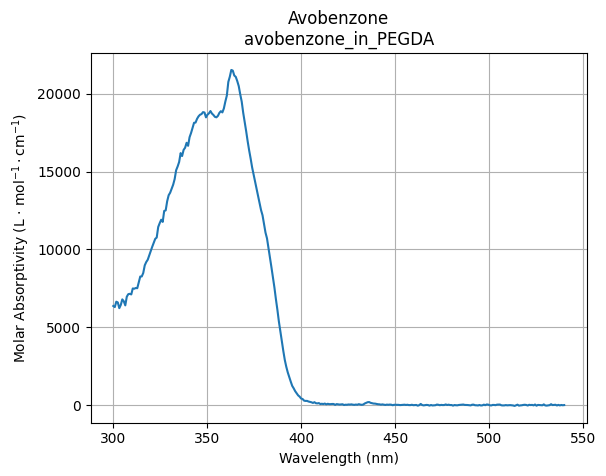

In [5]:
absorber_key = 'avobenzone_in_PEGDA'
absorber_avobenzone = data.absorbers[absorber_key]

fig, ax = plt.subplots()
ax.plot(absorber_avobenzone.wavelength, absorber_avobenzone.molar_absorptivity)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Molar Absorptivity (L $\cdot$ mol$^{-1} \cdot$cm$^{-1}$)')
ax.set_title(absorber_avobenzone.name + '\n' + absorber_key)
ax.grid()

### Example: source

As an example of an LED source, `data.sources['HR3v3_365nm_Visitech_370nm_shortpass']` contains the normalized emission spectrum of HR3v3 365 nm LED passed through an Asahi 370 nm short pass filter, which was measured on March 3, 2020.

In [6]:
help(data.sources['HR3v3_365nm_Visitech_370nm_shortpass'])

Help on SourceSpectrum in module spectra.sourcespectrum object:

class SourceSpectrum(builtins.object)
 |  SourceSpectrum(directory)
 |  
 |  Optical spectrum data.
 |  
 |  Attributes:
 |      name (str): Name of source.
 |      wavelength (numpy.ndarray): Array of wavelengths over which source spectrum is sampled.
 |      power (numpy.ndarray): Normalized power.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, directory)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  calc_power(self, wavelength)
 |      Given wavelength, interpolate corresponding power value.
 |      
 |      See numpy.interp documentation for interpolation details.
 |      
 |      Parameters
 |      ----------
 |      wavelength - array_like (can be single value or 1D list/numpy.array of values)
 |      
 |      Returns
 |      -------
 |      single value or 1D numpy array corresponding to shape of wavelength
 |  
 |  ----------------------------------------------------------

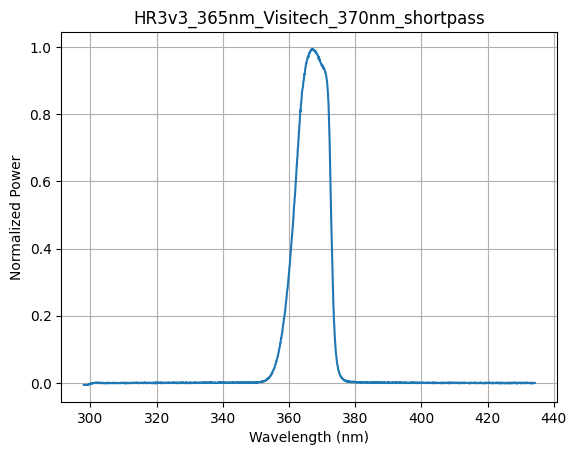

In [7]:
source_key = 'HR3v3_365nm_Visitech_370nm_shortpass'
source = data.sources[source_key]

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Normalized Power')
ax.set_title(source.name)
ax.grid()

# Compare absorber and source

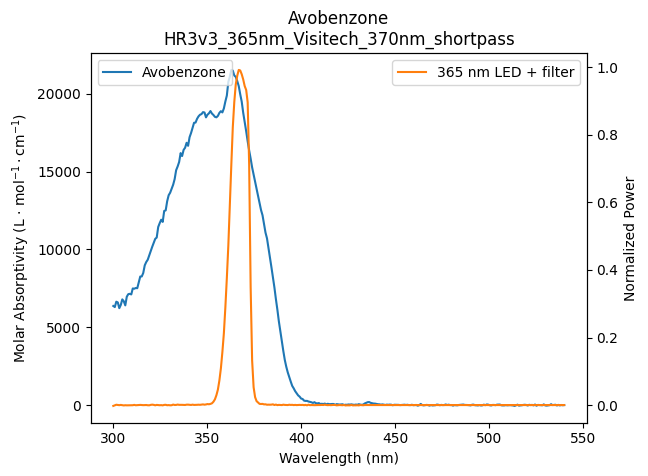

In [8]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(absorber_avobenzone.wavelength, absorber_avobenzone.molar_absorptivity, label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Molar Absorptivity (L $\cdot$ mol$^{-1} \cdot$cm$^{-1}$)')
ax.set_title(absorber_avobenzone.name + '\n' + source.name)
ax2.plot(absorber_avobenzone.wavelength, source.calc_power(absorber_avobenzone.wavelength), c='C1', label='365 nm LED + filter')
ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

Note the use of `source.calc_power(absorber_avobenzone.wavelength)` in plotting the source spectra, which samples the source spectra at the same wavelengths and over the same wavelength range as the avobenzone absorption data.

# Construct a resin

To construct a resin, we need one or more monomers, one or more absorbers, and a photoinitiator. As an example, let's construct a 0.38% avobenzone resin in PEGDA with 1% Irgacure 819.

The process of constructing a resin involves the following steps:

1. Define all constituent materials
2. Create a `Resin` object using the consituent materials.

## Define constituent materials

In [9]:
# Monomer
pegda = ResinConstituentMonomer(
    material=data.monomers['PEGDA'], 
    concentration_percent_monomer=100
)

# Absorber
avobenzone = ResinConstituentAbsorber(
    material=data.absorbers['avobenzone_in_PEGDA'],
    concentration_ww_percent=0.38
)

# Photoinitiator
irgacure819 = ResinConstituentAbsorber(
    material=data.photoinitiators['irgacure_819_in_PEGDA'],
    concentration_ww_percent=1.0
)

In the code above, note that we use the class `ResinConstituentAbsorber` for both absorbers and photoinitiators because their optical effect on the resin is the same, i.e., they each absorb light with a particular spectral absorbance.

## Create resin

In [10]:
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)

# Define an Irradiance object

An `Irradiance` object calculates the irradiance at one or more z positions as a function of wavelength for a particular combination of resin and source.

In [11]:
# Source
source = data.sources['HR3v3_365nm_Visitech_370nm_shortpass']

# Irradiance
irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

In [12]:
help(ArrayParams)

Help on class ArrayParams in module spectra.utilities:

class ArrayParams(builtins.tuple)
 |  ArrayParams(min_value: float, max_value: float, num_pnts: int)
 |  
 |  Container with named attributes for making 1D arrays of linearly spaced values.
 |  Intended for use with numpy.linspace.
 |  
 |  Attributes:
 |      min_value (float): Minimum value in array
 |      max_value (float): Maximum value in array
 |      num_pnts (int): number of values in array
 |  
 |  Example:
 |      wavelengths = np.linspace(*ArrayParams(300, 440, 281))
 |  
 |  Method resolution order:
 |      ArrayParams
 |      builtins.tuple
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __getnewargs__(self)
 |      Return self as a plain tuple.  Used by copy and pickle.
 |  
 |  __repr__(self)
 |      Return a nicely formatted representation string
 |  
 |  _asdict(self)
 |      Return a new dict which maps field names to their values.
 |  
 |  _replace(self, /, **kwds)
 |      Return a new ArrayPara

Note that `ArrayParams` returns an array of linearly spaced wavelength values from 300 to 440 nm, with 281 total values in the array.

# Calculate normalized dose

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PEG-100__Avo-0.38__Irg-1\nHR3v3_365nm_Visitech_370nm_shortpass'}, xlabel='z ($\\mu$m)', ylabel="D'(z)">)

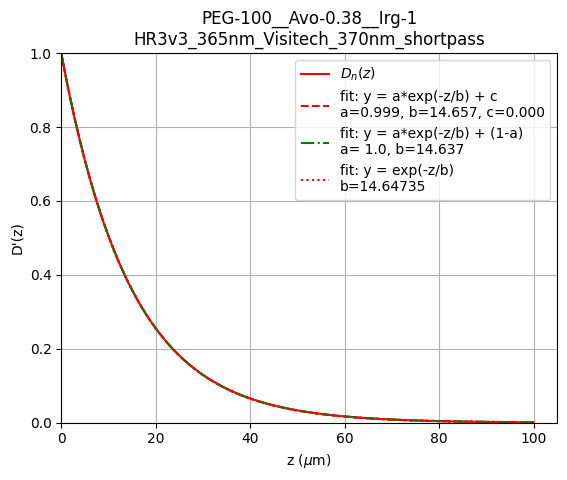

In [13]:
# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)

# Plot
norm_dose.plot(title=(norm_dose.irradiance.resin.name + "\n" + norm_dose.irradiance.source.name))

# Putting it all together

/Users/dallinminer/Documents/Research/3dprinter_spectra_and_tools/spectra/normalizeddose.py:132: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PEG-100__Avo-0.38__Irg-1\nHR3v3_365nm_Visitech_370nm_shortpass'}, xlabel='z ($\\mu$m)', ylabel="D'(z)">)

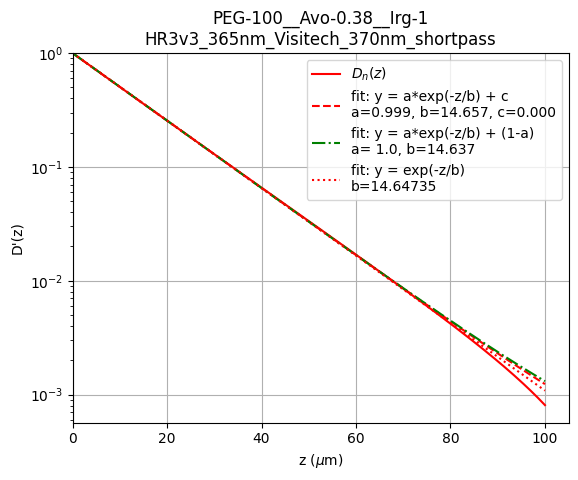

In [14]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA'],
    0.38
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure_819_in_PEGDA'],
    1.0
)
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)

# Source
source = data.sources['HR3v3_365nm_Visitech_370nm_shortpass']

# Irradiance
irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)

norm_dose.plot(title=(norm_dose.irradiance.resin.name + "\n" + norm_dose.irradiance.source.name))

# Comparing irradiances of filtered and unfiltered 365nm sources

Note: In the above example uses a 370nm shortpass filter on the 365nm LED source.

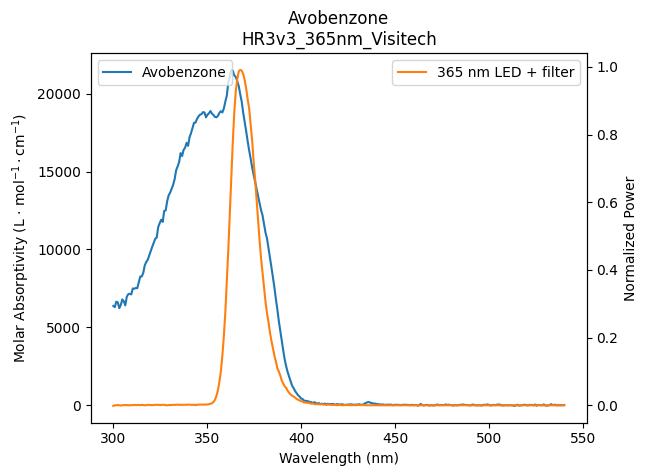

In [15]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA'],
    0.4565
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure_819_in_PEGDA'],
    1.0
)
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)

# Source
source = data.sources['HR3v3_365nm_Visitech']

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(absorber_avobenzone.wavelength, absorber_avobenzone.molar_absorptivity, label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Molar Absorptivity (L $\cdot$ mol$^{-1} \cdot$cm$^{-1}$)')
ax.set_title(absorber_avobenzone.name + '\n' + source.name)
ax2.plot(absorber_avobenzone.wavelength, source.calc_power(absorber_avobenzone.wavelength), c='C1', label='365 nm LED + filter')
ax2.set_ylabel('Normalized Power')
ax.legend(loc='upper left')
ax2.legend(loc='upper right');

Without this filter, the spectra Avobenzone does not fully cover the long wavelength tail of the LED. This results in a less desirable dose curve. 

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'PEG-100__Avo-0.46__Irg-1\nHR3v3_365nm_Visitech'}, xlabel='z ($\\mu$m)', ylabel="D'(z)">)

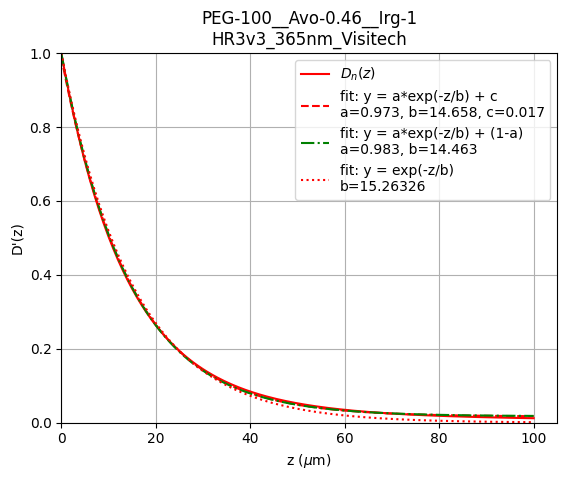

In [16]:
# Irradiance
irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=ArrayParams(300, 440, 281))

# z values for normalized dose calculations
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)

norm_dose.plot(title=(norm_dose.irradiance.resin.name + "\n" + norm_dose.irradiance.source.name))

Examine the a*exp(-z/b) + c fit. Compared to the previous filtered curve the c term is much higher (1.7% of irradiance even with extra 0.8% Avobenzone to make up for extra light). This is due to the undesirable long wavelength tail and will result in continued dosage of finished layers clogging negative features.